In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from ydata_profiling import ProfileReport

**Predict the age of abalone from physical measurements**

`Sex` - nominal -  M, F, and I (infant)

`Length` - continuous - mm -  Longest shell measurement

`Diameter` -  continuous - mm - perpendicular to length

`Height` - continuous - mm - with meat in shell

`Whole weight` - continuous - grams - whole abalone

`Shucked weight` - continuous - grams - weight of meat

`Viscera weight` - continuous - grams - gut weight (after bleeding)

`Shell weight` - continuous - grams - after being dried 

`Rings` - integer -  +1.5 gives the age in years (target)

# 1. EDA

### Загружу данные и посмотрю на них

In [15]:
df = pd.read_csv('abalone.csv')
df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,NaN,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [16]:
df.shape

(4177, 9)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4078 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4078 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4127 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


### Видно, что в датасете присутствуют лишь непрерывные признаки (кроме категориального 'Sex'), а также есть некоторое количество пропусков

In [18]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4078.000000,4177.000000,4078.000000,4177.000000,4177.000000,4127.000000,4177.000000
mean,0.523992,0.407840,0.139516,0.827306,0.359367,0.180594,0.239072,9.933684
std,0.120093,0.099286,0.041827,0.490348,0.221963,0.109614,0.138942,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.440500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.798500,0.336000,0.171000,0.235000,9.000000
75%,0.615000,0.480000,0.165000,1.150875,0.502000,0.253000,0.328250,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### Видно, что есть аномальные значения, от которых скорее всего в дальнейшем нужно будет избавиться

In [19]:
df.describe(include='object')

,Sex
count,4177
unique,4
top,M
freq,1447


**Но откуда 4 значения? Ведь по описанию датасета - 3**

In [20]:
df.Sex.unique()

array(['M', 'F', 'I', 'f'], dtype=object)

**Исправим ситуацию:**

In [21]:
df['Sex'] = df['Sex'].replace('f','F')

In [22]:
df.Sex.unique()

array(['M', 'F', 'I'], dtype=object)

### Создам отчет с помощью *ProfileReport*

In [20]:
report = ProfileReport(df)

In [21]:
report.to_file('abalone_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 8943.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

---

# 2. Однофакторный анализ

## Посмотрю распределения

In [23]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

### Sex

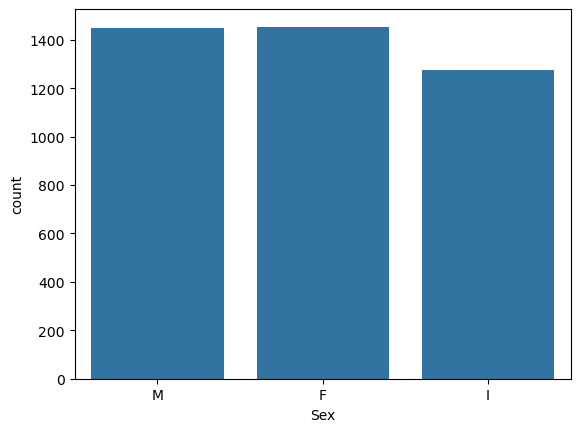

In [24]:
sns.countplot(data=df,x='Sex');

### Length

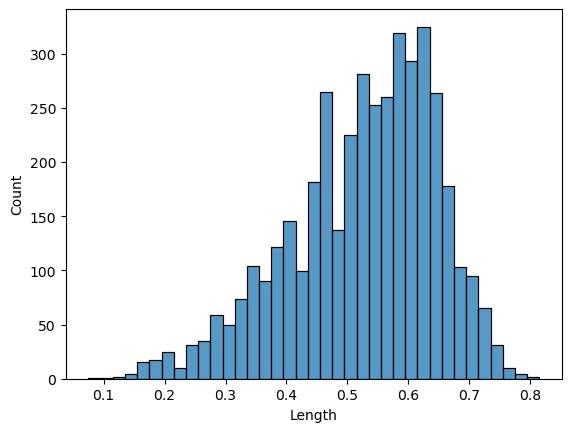

In [25]:
sns.histplot(data=df,x='Length');

### Diameter

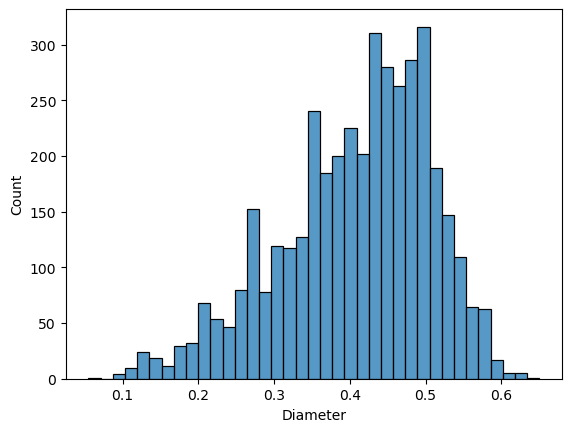

In [26]:
sns.histplot(data=df,x='Diameter');

### Height

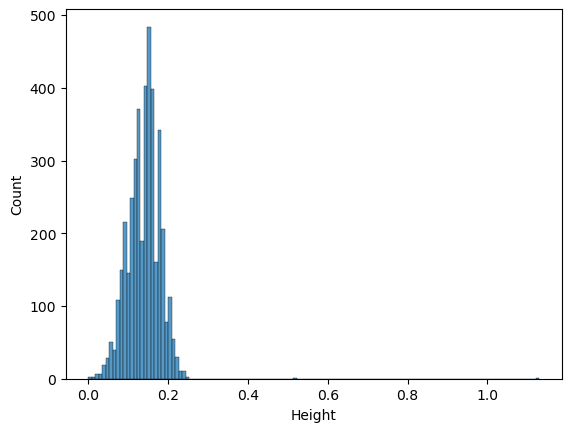

In [27]:
sns.histplot(data=df,x='Height');

**Избавлюсь от выбросов и нулевых значений:**

In [28]:
df = df[df['Height'] < 0.3]

In [29]:
df = df[df['Height'] > 0]

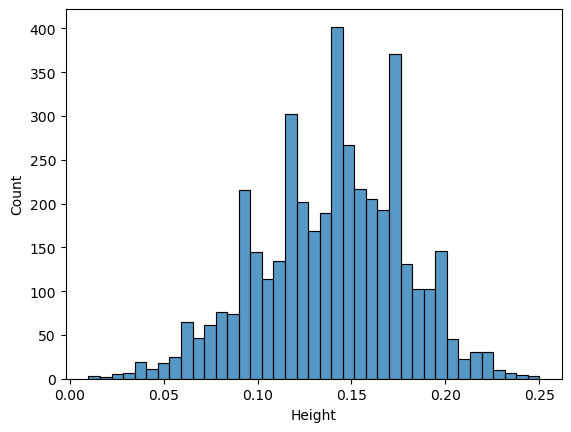

In [30]:
sns.histplot(data=df,x='Height');

### Whole weight

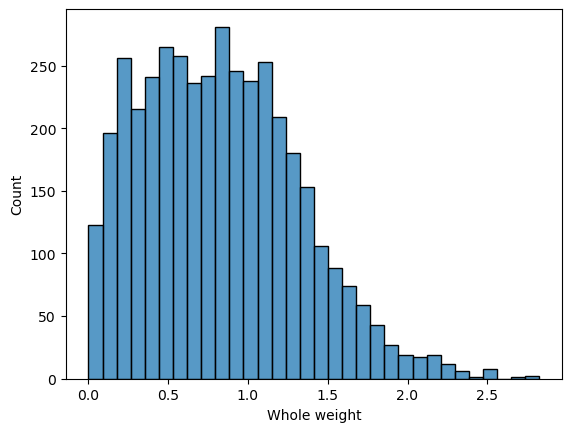

In [31]:
sns.histplot(data=df,x='Whole weight');

In [32]:
df['Whole weight'].describe()

count    4074.000000
mean        0.827292
std         0.489936
min         0.002000
25%         0.440500
50%         0.799250
75%         1.150875
max         2.825500
Name: Whole weight, dtype: float64

**Уберу всё что заходит за полтора межквартильных размаха:**

In [33]:
# 1.5*IQR+Q3
1.5 * (1.150625 - 0.440375) + 1.150625

2.216

In [34]:
df = df[df['Whole weight'] < 2.216]

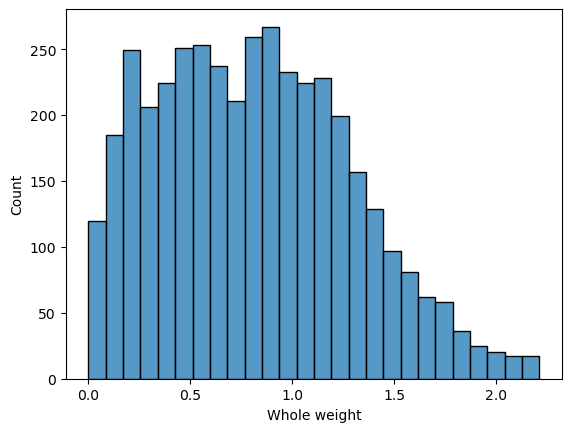

In [35]:
sns.histplot(data=df,x='Whole weight');

### Shucked weight

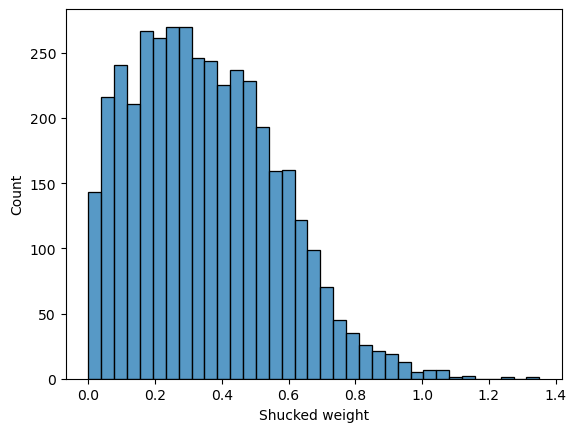

In [36]:
sns.histplot(data=df,x='Shucked weight');

In [37]:
df['Shucked weight'].describe()

count    4045.000000
mean        0.353395
std         0.213117
min         0.001000
25%         0.182000
50%         0.334000
75%         0.497500
max         1.351000
Name: Shucked weight, dtype: float64

**Уберу выбросы по тому же принципу:**

In [38]:
1.5 * (0.497500 - 0.182000) + 0.497500

0.97075

In [39]:
df = df[df['Shucked weight'] < 0.97075]

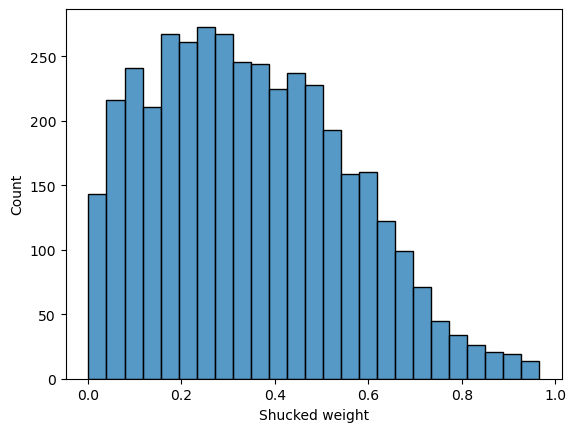

In [40]:
sns.histplot(data=df,x='Shucked weight');

### Viscera weight

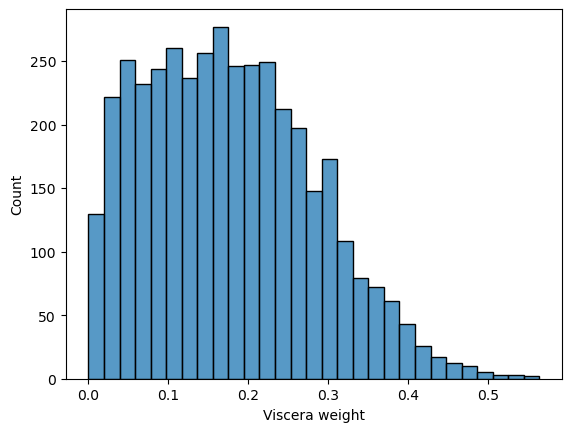

In [41]:
sns.histplot(data=df,x='Viscera weight');

In [42]:
df['Viscera weight'].describe()

count    4022.000000
mean        0.176523
std         0.104759
min         0.000500
25%         0.092000
50%         0.168500
75%         0.247500
max         0.564000
Name: Viscera weight, dtype: float64

In [43]:
1.5 * (0.247500 - 0.092000) + 0.247500

0.48075

In [44]:
df = df[df['Viscera weight'] < 0.48075]

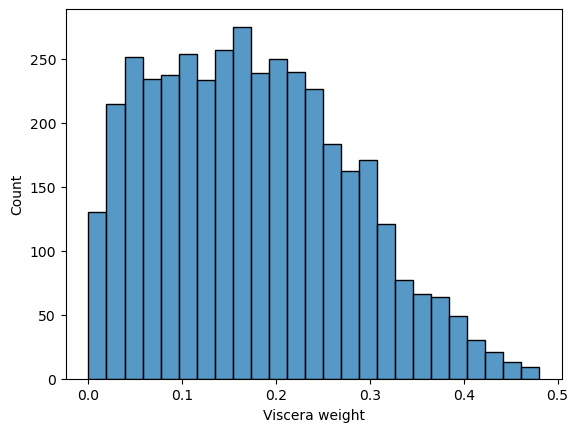

In [45]:
sns.histplot(data=df,x='Viscera weight');

### Shell weight

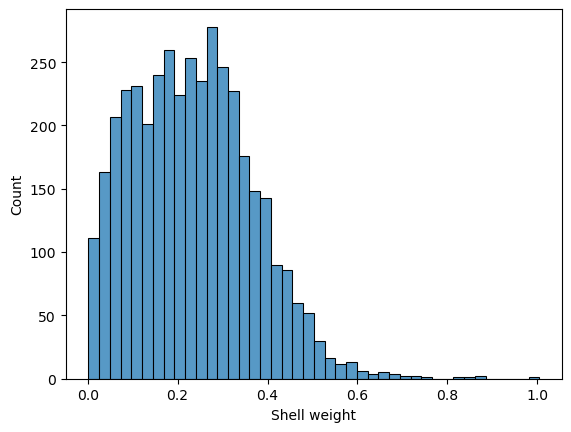

In [46]:
sns.histplot(data=df,x='Shell weight');

In [47]:
df['Shell weight'].describe()

count    3959.000000
mean        0.233350
std         0.133154
min         0.001500
25%         0.129000
50%         0.229500
75%         0.320000
max         1.005000
Name: Shell weight, dtype: float64

In [48]:
1.5 * (0.320000 - 0.129000) + 0.320000

0.6065

In [49]:
df = df[df['Shell weight'] < 0.6065]

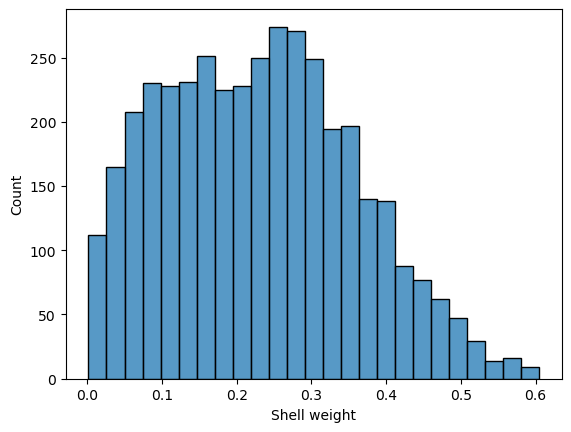

In [50]:
sns.histplot(data=df,x='Shell weight');

## Пропуски

In [51]:
df.isnull().sum()

Sex                0
Length             0
Diameter          93
Height             0
Whole weight       0
Shucked weight     0
Viscera weight     0
Shell weight       0
Rings              0
dtype: int64

**Заполню пропуски медианным значением:**

In [52]:
df.Diameter.median()

0.42

In [53]:
df.fillna(0.42,inplace=True)

In [54]:
df.to_csv('abalone_clear.csv')

### Поглядим на то, что получается:

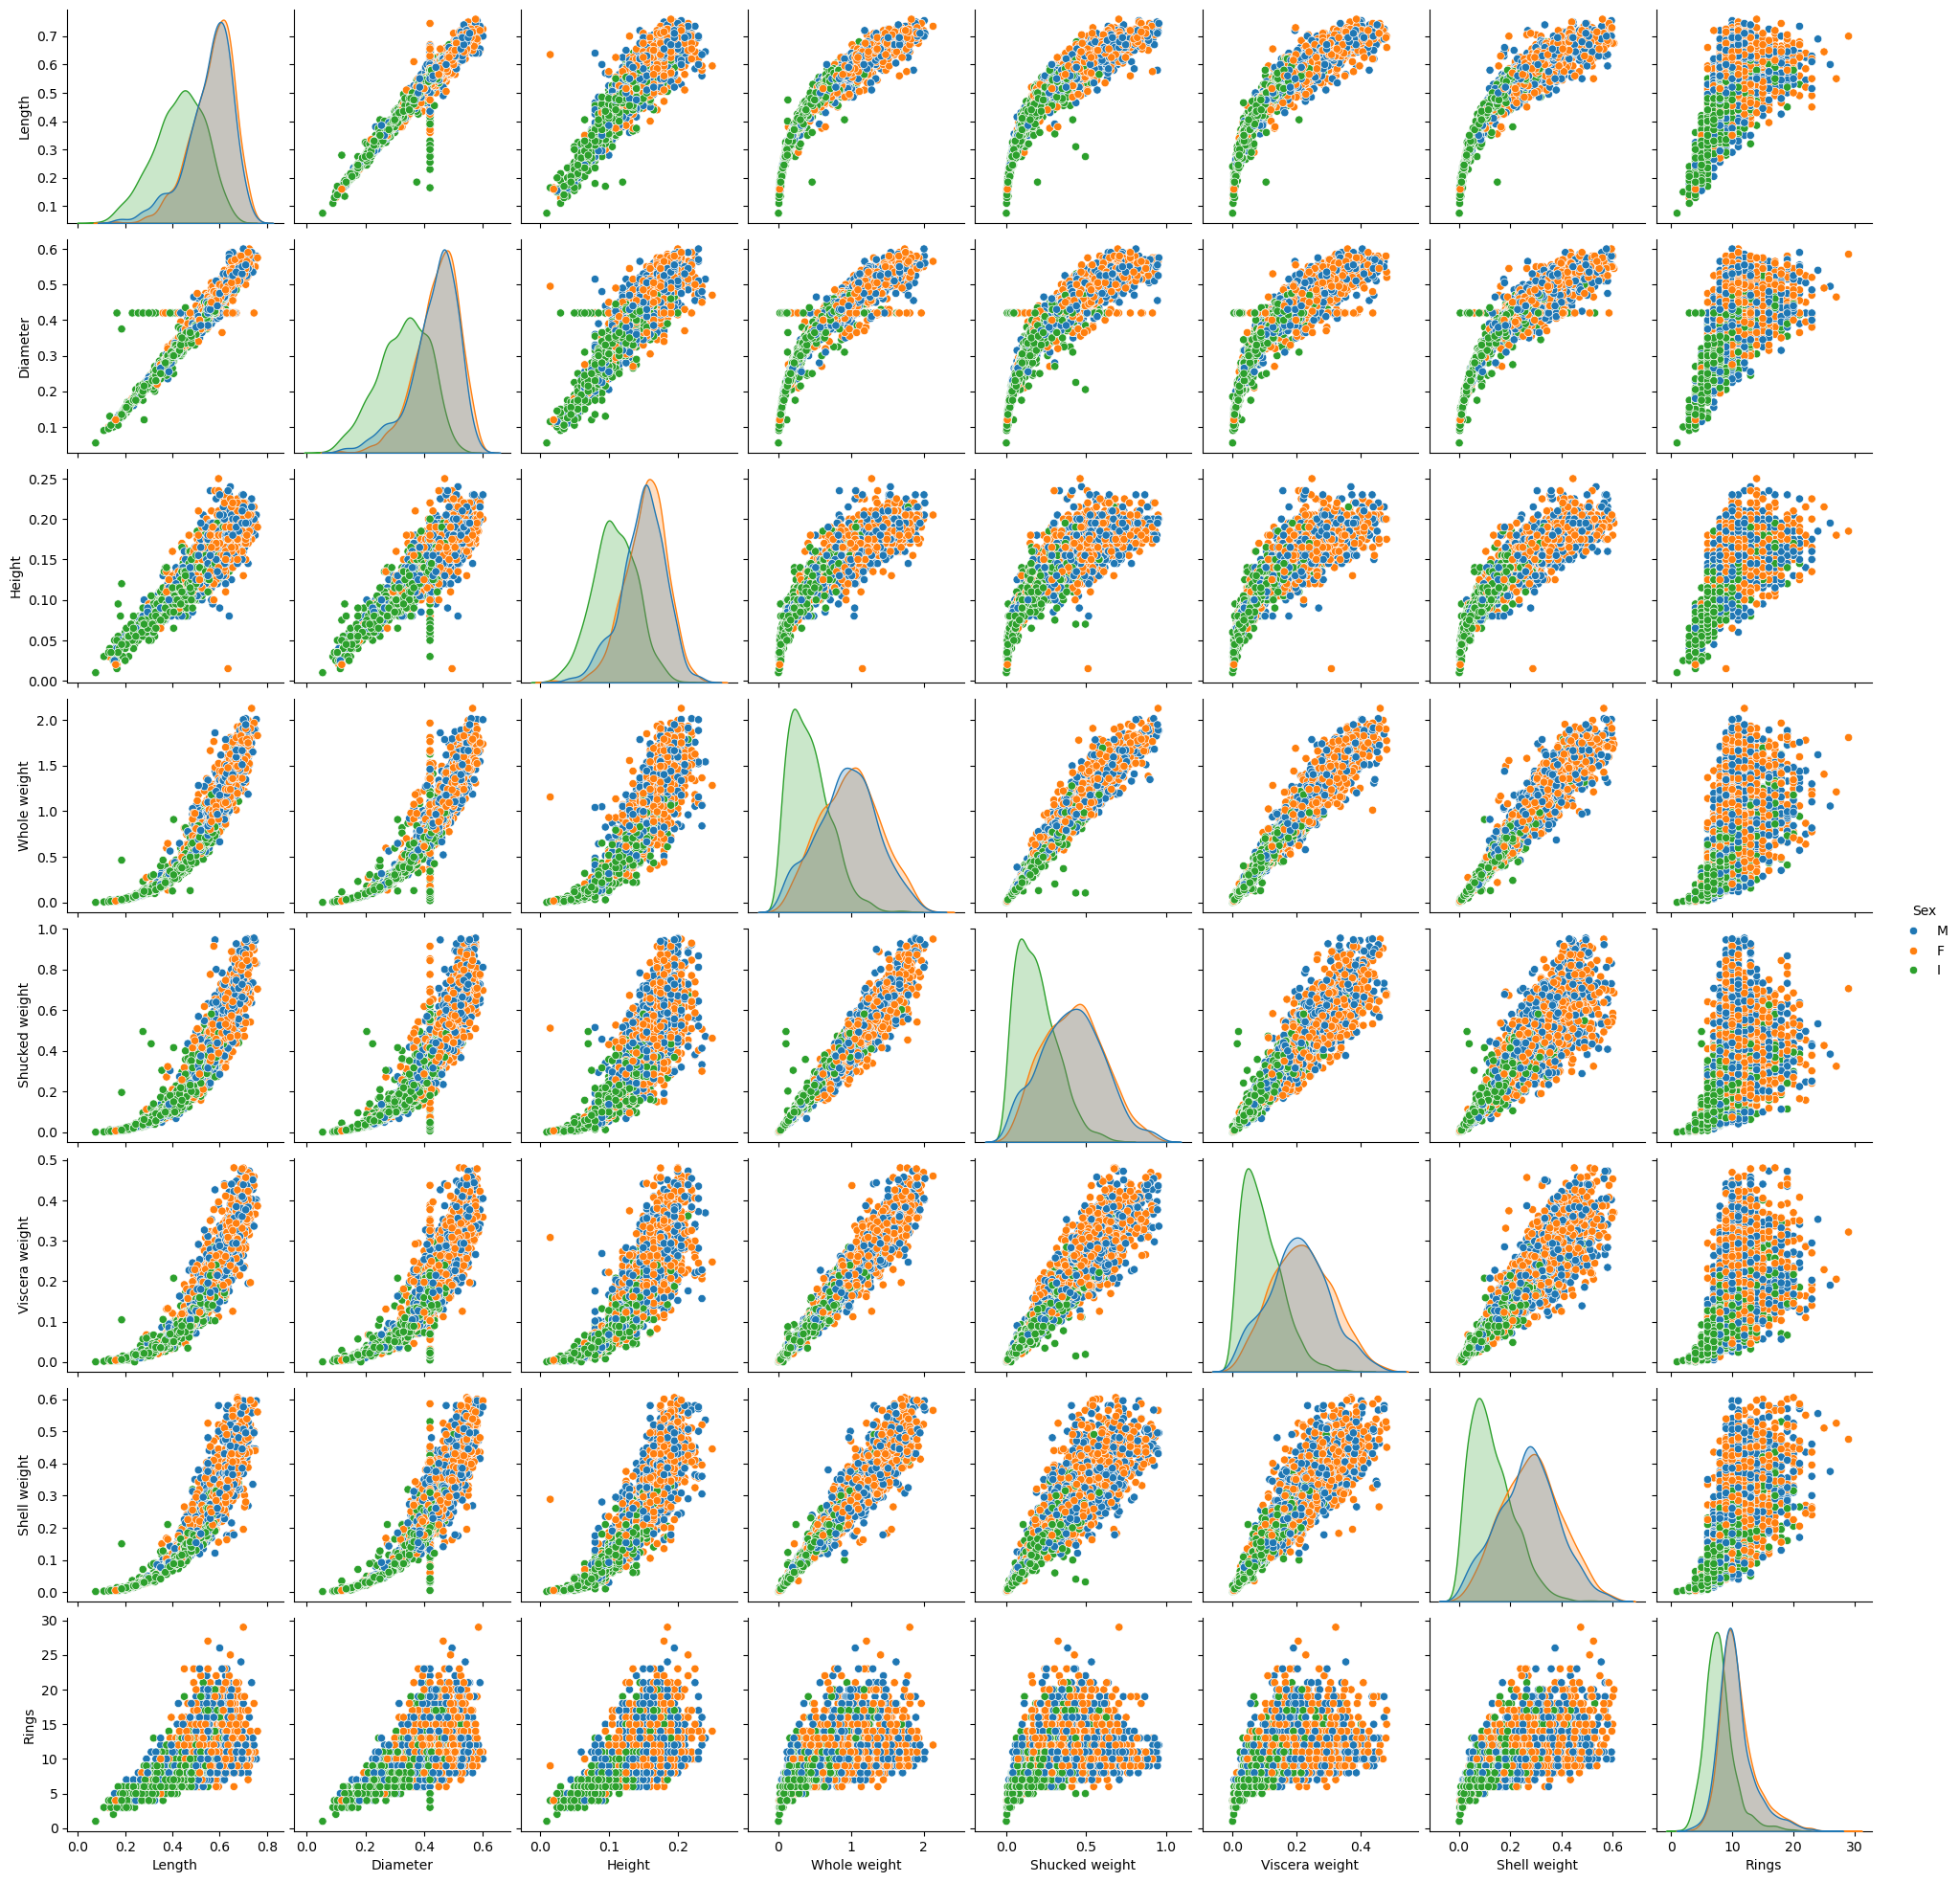

In [58]:
sns.pairplot(df,hue='Sex');

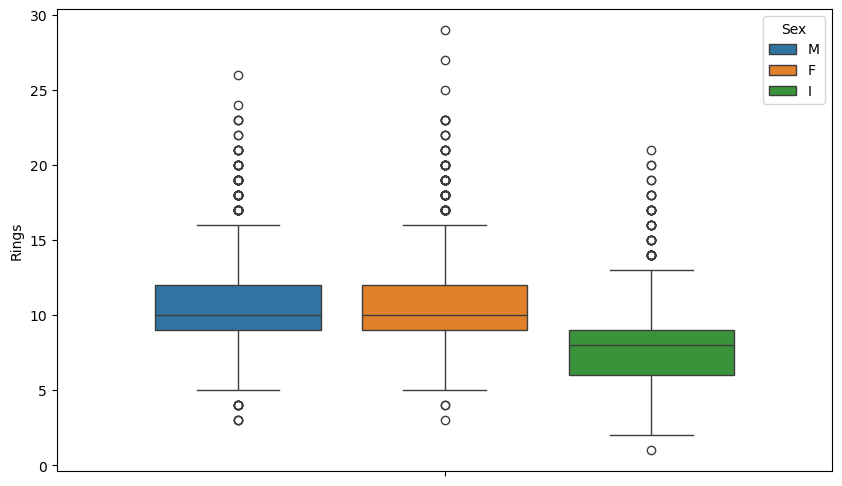

In [78]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,y='Rings',hue='Sex',gap=1.8);

### Можно сделать вывод, что самки практически не отличаются от самцов. Сильно выбиваются лишь младенцы

---

# 3. Матрицы корреляций

**Построю матрицы всех трёх типов:**

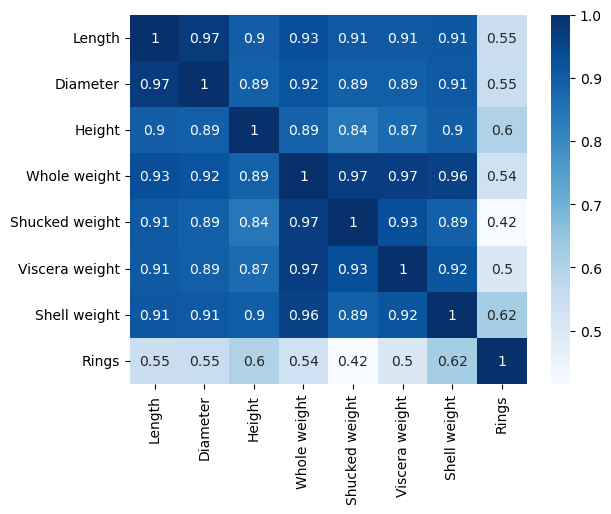

In [80]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues');

**Слабая линейная связь с Rings (0.42–0.62), высокая мультиколлинеарность между признаками**

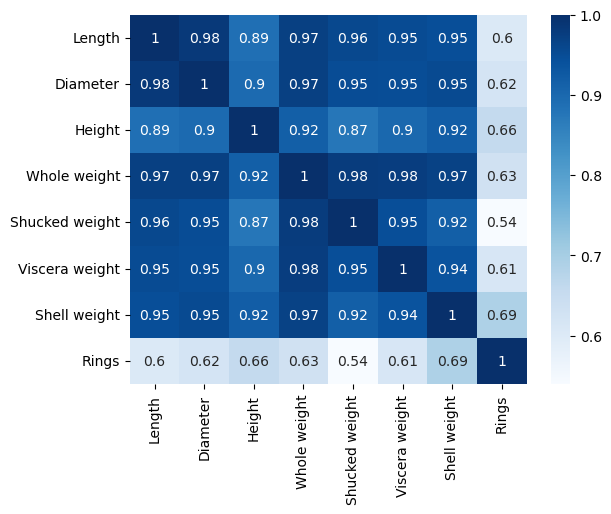

In [44]:
sns.heatmap(df.corr(numeric_only=True,method='spearman'),annot=True,cmap='Blues');

**Более высокие значения (0.54–0.69), указывает на нелинейную монотонную зависимость**

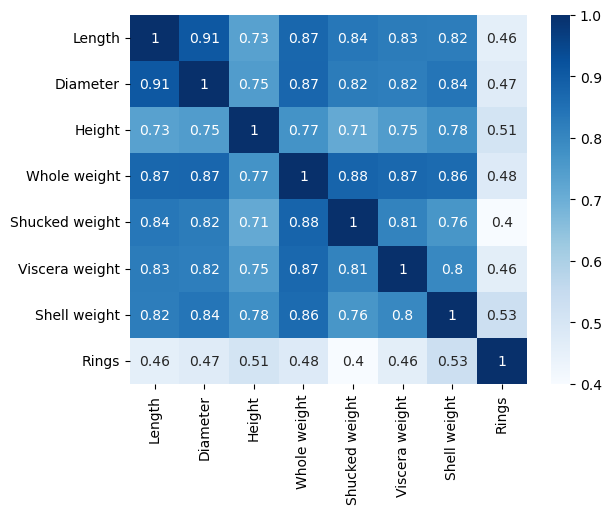

In [45]:
sns.heatmap(df.corr(numeric_only=True,method='kendall'),annot=True,cmap='Blues');

**Самые низкие коэффициенты (0.40–0.53), но устойчив к выбросам и подтверждает те же тренды**

---

# 4. Анализ целевой переменной

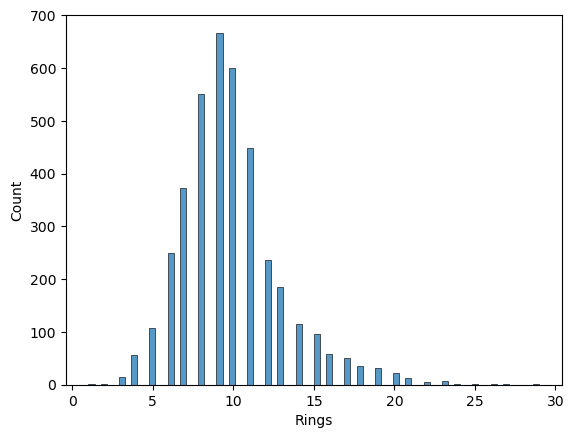

In [83]:
sns.histplot(data=df,x='Rings');

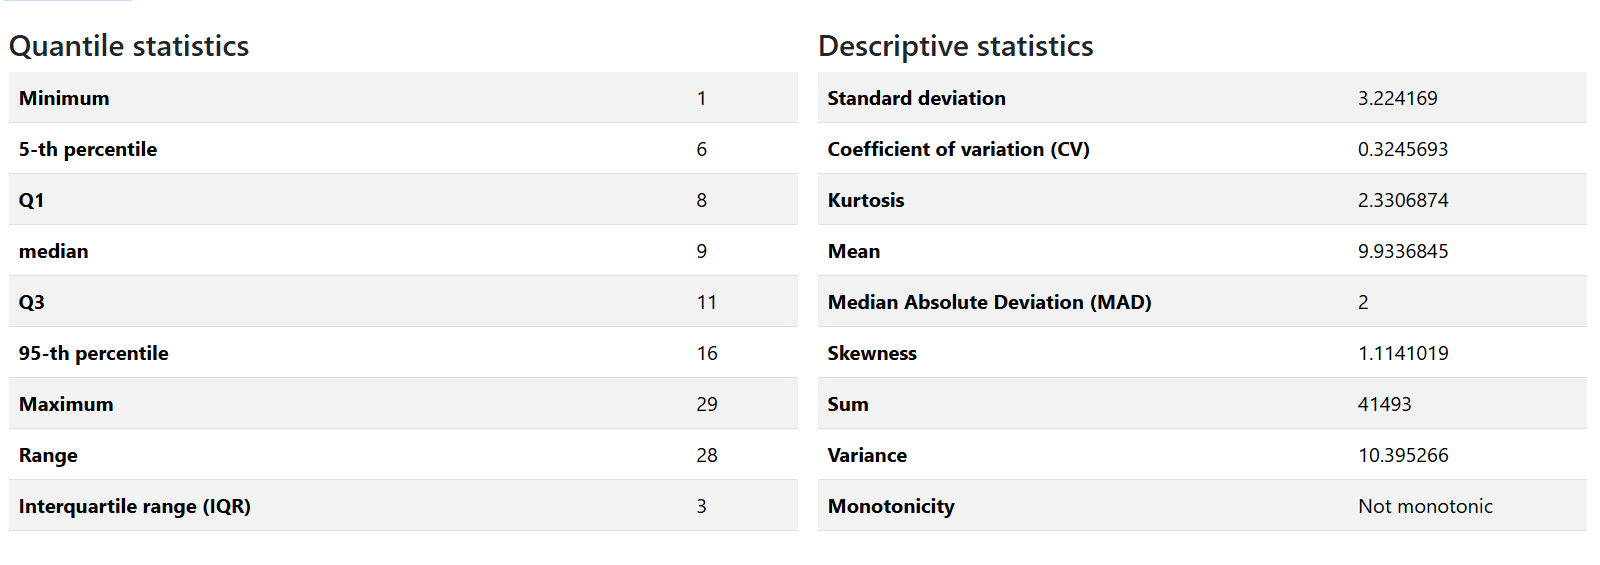

### Выглядит как нормальное распределение, скошенное вправо(skewness 1.11) с высокой концентрацией значений вокруг среднего (kurtosis 2.33). В связи с этим у модели будут проблемы с предсказанием большого количества колец

---

# 5. Pandas vs Polars

In [38]:
import polars as pl
import time

Определяем, сколько раз нужно продублировать до 1 000 000 записей

In [39]:
original_len = len(df)
target_len = 1000000
repeat_times = target_len // original_len + 1

Создаём увеличенный датасет через дублирование

In [41]:
df_large_pd = pd.concat([df] * repeat_times, ignore_index=True)

In [43]:
len(df_large_pd)

1002915

Конвертируем в Polars

In [44]:
df_large_pl = pl.from_pandas(df_large_pd)

In [45]:
df_large_pd.to_csv('large_dataset.csv', index=False)

### Загрузка данных

In [46]:
# Pandas загрузка
start = time.time()
pd.read_csv('large_dataset.csv')
print(f"  Pandas: {time.time() - start:.3f} сек")

  Pandas: 0.631 сек


In [47]:
# Polars загрузка
start = time.time()
pl.read_csv('large_dataset.csv')
print(f"  Polars: {time.time() - start:.3f} сек")

  Polars: 0.262 сек


### Фильтрация данных

In [48]:
# Pandas
start = time.time()
filtered_pd = df_large_pd[df_large_pd['Rings'] > 10]
print(f"  Pandas: {time.time() - start:.3f} сек, отфильтровано {len(filtered_pd)} строк")

  Pandas: 0.030 сек, отфильтровано 335070 строк


In [49]:
# Polars
start = time.time()
filtered_pl = df_large_pl.filter(pl.col('Rings') > 10)
print(f"  Polars: {time.time() - start:.3f} сек, отфильтровано {len(filtered_pl)} строк")

  Polars: 0.166 сек, отфильтровано 335070 строк


### Агрегация данных

In [50]:
# Pandas
start = time.time()
agg_pd = df_large_pd.groupby('Rings').agg({
    'Length': 'mean',
    'Whole weight': 'mean',
    'Shell weight': 'mean'
})
print(f"  Pandas: {time.time() - start:.3f} сек")

  Pandas: 0.056 сек


In [51]:
# Polars
start = time.time()
agg_pl = df_large_pl.group_by('Rings').agg([
    pl.col('Length').mean(),
    pl.col('Whole weight').mean(),
    pl.col('Shell weight').mean()
])
print(f"  Polars: {time.time() - start:.3f} сек")

  Polars: 0.132 сек


**В данном случае Polars не оказался быстрее**

---